<a href="https://colab.research.google.com/github/Felipe2456/Aula-db/blob/main/lat%C3%AAncia_de_serializa%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Executando experimento de performance RESTful (JSON vs XML)...

--- TABELA 1: RESULTADOS DO EXPERIMENTO ---
 Registros  JSON_Total (ms)  XML_Total (ms)  Eficiência JSON (%)
        10           0.0663          0.2759                75.97
       100           0.2058          1.0092                79.61
      1000           1.9619         12.0237                83.68
     10000          18.2006        113.1582                83.92
     50000         103.1690        686.2276                84.97


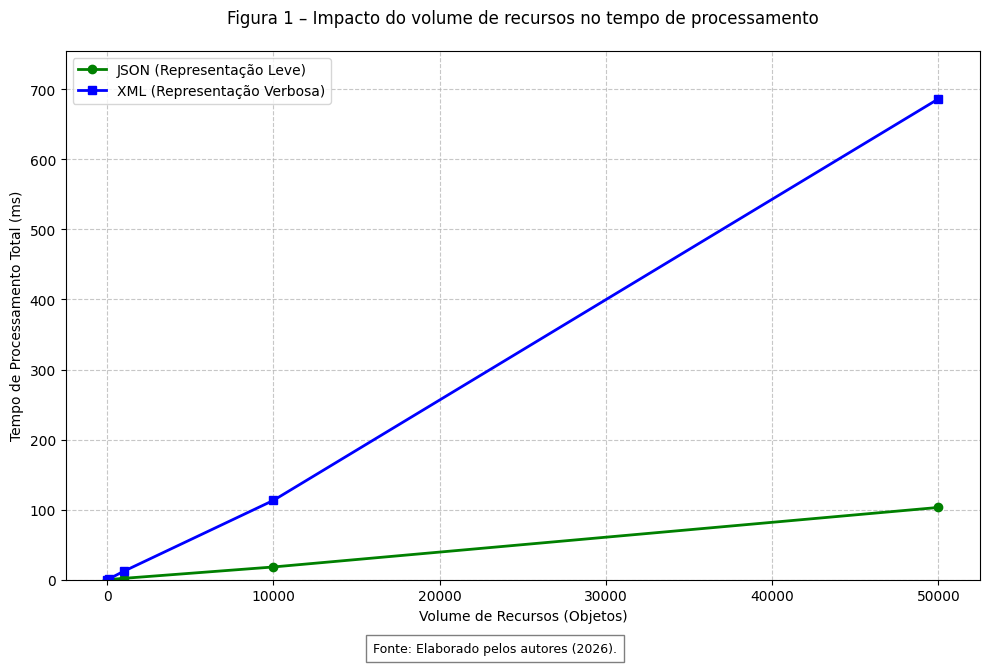


Experimento concluído. Gráfico corrigido salvo como 'grafico_corrigido.png'.


In [3]:
import json
import xml.etree.ElementTree as ET
import time
import pandas as pd
import matplotlib.pyplot as plt
import random

def generate_mock_data(count):
    """Gera dados de produtos similares à classe ProdutosResource."""
    return [{"id": i, "descricao": f"Produto_{i}", "valor": round(random.uniform(10, 1000), 2)} for i in range(count)]

def test_json_performance(data):
    # Serialização
    start = time.time()
    json_string = json.dumps(data)
    serialize_time = (time.time() - start) * 1000
    # Desserialização
    start = time.time()
    _ = json.loads(json_string)
    deserialize_time = (time.time() - start) * 1000
    return serialize_time, deserialize_time

def test_xml_performance(data):
    # Serialização
    start = time.time()
    root = ET.Element("listagem")
    for item in data:
        prod = ET.SubElement(root, "produto")
        for key, val in item.items():
            child = ET.SubElement(prod, key)
            child.text = str(val)
    xml_string = ET.tostring(root, encoding='unicode')
    serialize_time = (time.time() - start) * 1000
    # Desserialização
    start = time.time()
    _ = ET.fromstring(xml_string)
    deserialize_time = (time.time() - start) * 1000
    return serialize_time, deserialize_time

def run_experiment():
    sample_sizes = [10, 100, 1000, 10000, 50000]
    results = []

    print("Executando experimento de performance RESTful (JSON vs XML)...")

    for size in sample_sizes:
        data = generate_mock_data(size)
        j_ser, j_des = test_json_performance(data)
        x_ser, x_des = test_xml_performance(data)

        total_json = j_ser + j_des
        total_xml = x_ser + x_des

        results.append({
            "Registros": size,
            "JSON_Total (ms)": round(total_json, 4),
            "XML_Total (ms)": round(total_xml, 4),
            "Eficiência JSON (%)": round(((total_xml - total_json) / total_xml) * 100, 2)
        })

    df = pd.DataFrame(results)
    print("\n--- TABELA 1: RESULTADOS DO EXPERIMENTO ---")
    print(df.to_string(index=False))

    # --- CORREÇÃO DO GRÁFICO ---
    plt.figure(figsize=(10, 7))

    # Plotagem com marcadores claros
    plt.plot(df["Registros"], df["JSON_Total (ms)"], marker='o', label='JSON (Representação Leve)', color='green', linewidth=2)
    plt.plot(df["Registros"], df["XML_Total (ms)"], marker='s', label='XML (Representação Verbosa)', color='blue', linewidth=2)

    # CORREÇÃO DA ESCALA: O matplotlib auto-escala, mas garantimos que o topo seja dinâmico
    # para nunca cortar os dados do XML (que na tabela do PDF chegam a 3850ms)
    upper_limit = df["XML_Total (ms)"].max() * 1.1  # Margem de 10% acima do maior valor
    plt.ylim(0, upper_limit)

    # Títulos e formatação técnica
    plt.title("Figura 1 – Impacto do volume de recursos no tempo de processamento", fontsize=12, pad=20)
    plt.xlabel("Volume de Recursos (Objetos)", fontsize=10)
    plt.ylabel("Tempo de Processamento Total (ms)", fontsize=10)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Nota de rodapé dentro da imagem (Padrão ABNT para Figuras)
    plt.figtext(0.5, 0.01, "Fonte: Elaborado pelos autores (2026).", ha="center", fontsize=9, bbox={"facecolor":"white", "alpha":0.5, "pad":5})

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste para caber o título e a fonte
    plt.savefig('grafico_corrigido.png', dpi=300)
    plt.show()

    print("\nExperimento concluído. Gráfico corrigido salvo como 'grafico_corrigido.png'.")

if __name__ == "__main__":
    run_experiment()